In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp2d
from scipy.signal import find_peaks
from skimage import filters
from analyzer import *



# Single example

0.017097669163278553 0.021342261462600588
[(0.017097669163278553, 0.016983684702189982), (0.021342261462600588, 0.021199979719516655), (0.2222245237015701, 0.2423579324691326), (0.33851959005932386, 0.3403376338630138)]


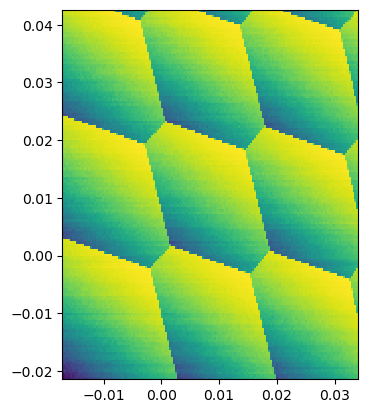

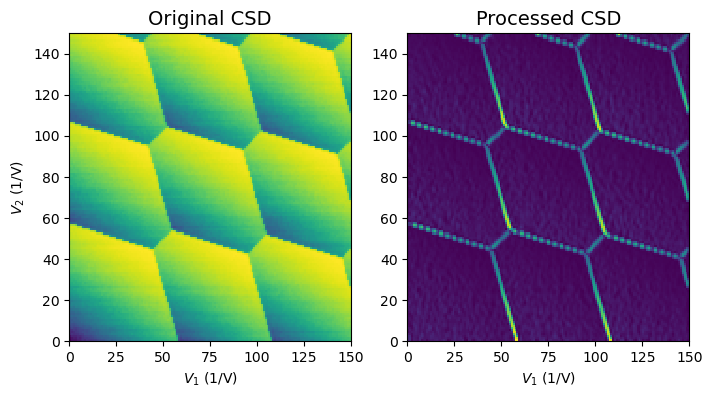

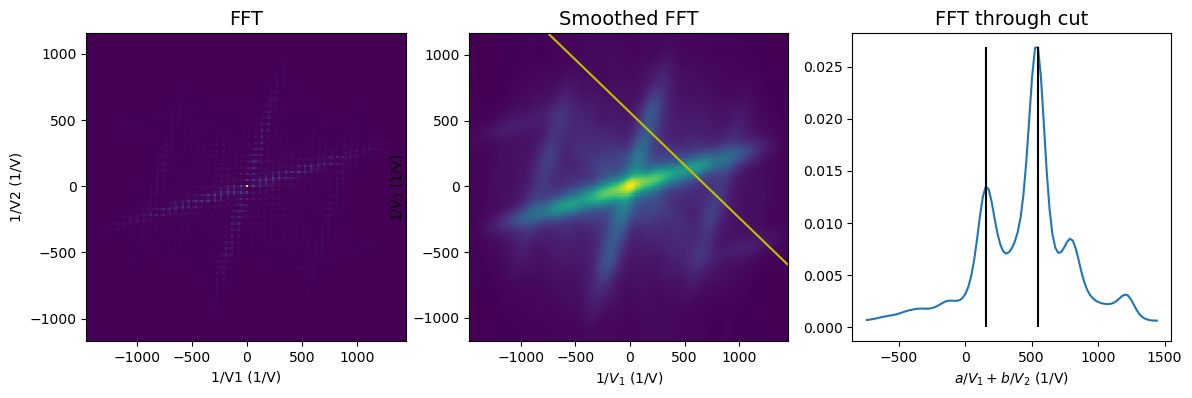

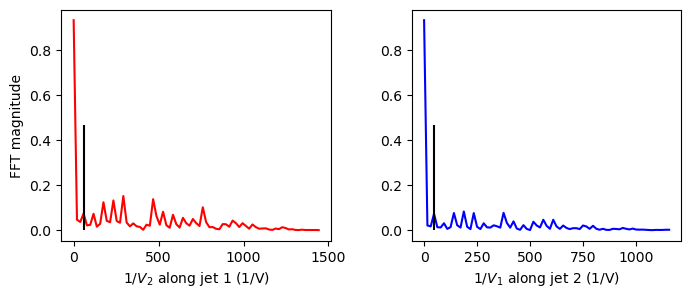

In [2]:
id = 4
csd = np.load(f'data/{0}_{id}_csd.npy')
xexp = np.load(f'data/{0}_{id}_xexp.npy')
yexp = np.load(f'data/{0}_{id}_yexp.npy')
dVx, dVy, theta1, theta2 = np.load(f'data/{0}_{id}_truth.npy')
plt.pcolormesh(xexp, yexp, csd)
#set aspect equal 
plt.gca().set_aspect('equal', adjustable='box')

results = analyze_csd(csd, v1 = xexp, v2 = yexp, plot = True)


res = ([(results['coulomb_diamond_size_v1'], dVx), 
            (results['coulomb_diamond_size_v2'], dVy),
                (results['cross_angle1'], theta1),
                (results['cross_angle2'], theta2)])
print(res)

## Scan through the data

Failed at 0_0
0.017013474148548993 0.027839880101147334
0.0391436652306787 0.06456330881230293
0.06427035986742574 0.03585184865973097
0.017097669163278553 0.021342261462600588
0.02453421607389299 0.030989024240385063
0.03760473258662792 0.05090158933166843
0.042340837933653105 0.024751417012832885
0.02731254767766103 0.025077179857999583
0.021101462461462116 0.02107083044374704
0.02106816301713811 0.030420195848687537
0.027253011867755906 0.029531759065162807
0.05701026275923801 0.027352666989285783
0.017902777356373217 0.06161539981836515
0.022819841203368038 0.026763648961886616
0.02955357907485079 0.02607151286170492
0.0726150005628777 0.07162693344757583
0.027522403167094294 0.03646813061011743
0.02815396124689513 0.04203777525572453
0.02350645052305537 0.03263711654029923
0.022938748351397815 0.028567897117672335
0.026410111172482306 0.0759535658864517
0.05250631217978384 0.030551445793623733
0.03843771582867639 0.02713055349544517
0.030518607353440152 0.026543107790164173
0.0339

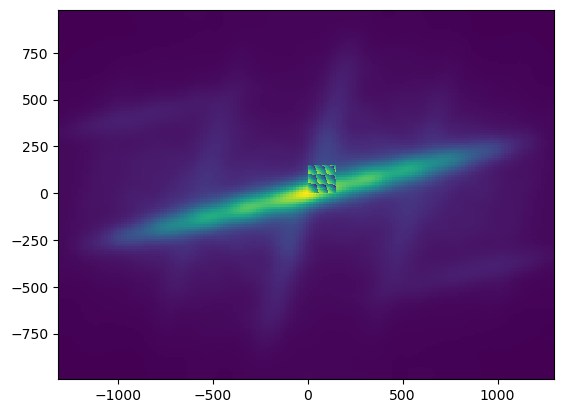

In [3]:

noise_levels = np.logspace(-5.5,-4,10)
Nsamples = 10
accuracy = []
for x, noise in enumerate(noise_levels):
    accuracy.append([])
    for n in range(Nsamples):
        xexp = np.load(f'data/{x}_{n}_xexp.npy')
        yexp = np.load(f'data/{x}_{n}_yexp.npy')
        csd = np.load(f'data/{x}_{n}_csd.npy')
        dVx, dVy, theta1, theta2 = np.load(f'data/{x}_{n}_truth.npy')
        try:
            results = analyze_csd(csd, v1 = xexp, v2 = yexp, plot = False)
            accuracy[-1].append([(results['coulomb_diamond_size_v1'] - dVx)/dVx, 
                        (results['coulomb_diamond_size_v2'] - dVy)/dVy, 
                        (results['cross_angle1'] - theta1)/theta1, 
                            (results['cross_angle2'] - theta2)/theta2])
            
            accuracy[-1][-1] = np.abs(accuracy[-1][-1])**2

        except:
            plt.pcolormesh(csd)
            print(f"Failed at {x}_{n}")
        

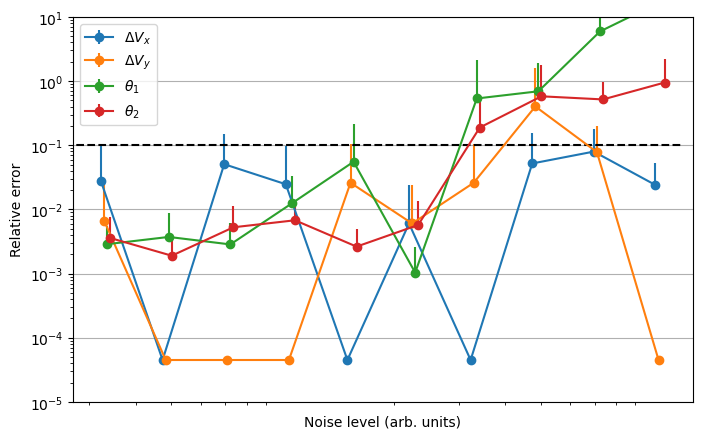

In [61]:
# plot the data
avg = {"vx": [], "vy": [], "theta1": [], "theta2": []}
std = {"vx": [], "vy": [], "theta1": [], "theta2": []}
for acc_noise in accuracy:
    mean = np.mean(acc_noise, axis = 0)
    sig = np.std(acc_noise, axis = 0)
    avg["vx"].append(mean[0])
    avg["vy"].append(mean[1])
    avg["theta1"].append(mean[2])
    avg["theta2"].append(mean[3])
    std["vx"].append(sig[0])
    std["vy"].append(sig[1])
    std["theta1"].append(sig[2])
    std["theta2"].append(sig[3])
    

shift = 0.02
plt.figure(figsize=(8,5))
plt.errorbar(noise_levels * (1 + shift), avg['vx'], yerr=[np.zeros_like(std['vx']), std['vx']], marker="o", label=r'$\Delta V_x$')
plt.errorbar(noise_levels * (1 + 2 * shift), avg['vy'], yerr=[np.zeros_like(std['vy']), std['vy']], marker="o", label=r'$\Delta V_y$')
plt.errorbar(noise_levels * (1 + 3 * shift), avg['theta1'], yerr=[np.zeros_like(std['theta1']), std['theta1']], marker="o", label=r'$\theta_1$')
plt.errorbar(noise_levels * (1 + 4 * shift), avg['theta2'], yerr=[np.zeros_like(std['theta2']), std['theta2']], marker="o", label=r'$\theta_2$')
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-5,1e1)
plt.grid()
plt.xlabel("Noise level (arb. units)")
plt.ylabel("Relative error")
plt.xticks([])
plt.hlines(1e-1, noise_levels[0]/2, 1.2*noise_levels[-1], color="black", linestyle="--")


